# Angular Spreading Discrete Models Tutorial

Wave energy is rarely confined to a single direction. The angular spreading function \(D(\theta)\) describes how energy is distributed over directions. Integrating \(D(\theta)\) over all angles equals 1, so it acts as a directional probability density. WaveSpec represents angular spreading as:

1) **Continuous model**: a PDF (e.g., Normal, Von Mises, Donelan-Banner, Cosine-Power) over angle
2) **Truncation**: realistic bounds $[\theta_{min}, \theta_{max}]$ via `TruncatedModel`
3) **Discretization**: sample `nθ` edges → `nθ-1` bins with central angles, bandwidths, and weights

The result is a `DiscreteAngularSpreading` object that pairs naturally with discrete frequency spectra to build directional sea states.

In [1]:
using WaveSpec
using WaveSpec.AngularSpreading
using WaveSpec.Truncation
using Distributions
using Plots

# Set a consistent plotting theme
default(fmt=:png, legend=:topright, grid=false)

┌ Info: WaveSpec initialized: Ready for spectral sea state synthesis.
└ @ WaveSpec /home/elmanyer/Documents/TU-Delft/WaveSpec.jl/src/WaveSpec.jl:33


This notebook explains how WaveSpec models directional spreading of wave energy. You will learn to:
- Build continuous angular distributions and truncate them to realistic bounds
- Convert continuous models into discrete angular bins with `DiscreteAngularSpreading`
- Use built-in spreading models (uniform, normal, cosine-power, Von Mises, Donelan-Banner)
- Inspect sampled angles, bin widths, and weights
- Control units (radians vs degrees) and reproducibility via seeds
- Create long-crested (single-direction) and multi-directional seas

## Truncation: building realistic PDFs
All discrete spreading structures in WaveSpec are built from a **truncated** continuous distribution using `TruncatedModel`. Truncation ensures:
- Samples stay within ([a, b])
- The PDF is renormalized on that interval

`TruncatedModel(dist, a, b)` stores the base distribution, bounds, and normalization constants so that `pdf`, `cdf`, and `rand` operate on the truncated support.

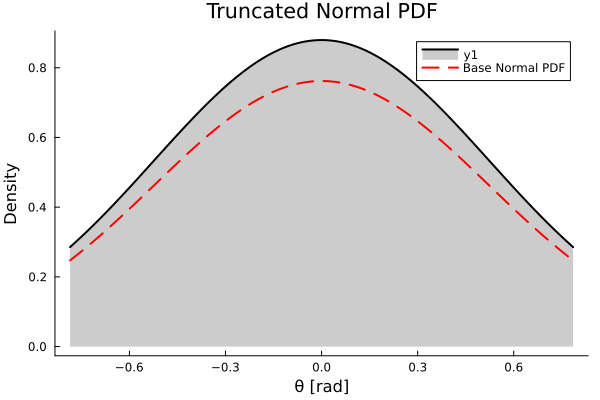

In [10]:
# Example: truncate a Normal PDF to a finite sector
μ = 0.0                 # mean direction [rad]
σ = π/6                 # std dev [rad]
θmin, θmax = -π/4, π/4  # bounds [rad]

base_dist = Normal(μ, σ)

# Plot base and truncated distributions
trunc_dist = TruncatedModel(base_dist, θmin, θmax)

# Plot truncated PDF
θ_range = range(θmin, θmax, length=400)
p_trunc = plot(θ_range, [pdf(trunc_dist, θ) for θ in θ_range],
               xlabel="θ [rad]", ylabel="Density",
               title="Truncated Normal PDF", color=:black, lw=2, fillrange=0, fillalpha=0.2)
plot!(p_trunc, θ_range, [pdf(base_dist, θ) for θ in θ_range],
      label="Base Normal PDF", linestyle=:dash, color=:red, lw=2)

## From truncated PDF to discrete bins
`DiscreteAngularSpreading` samples `nθ` angles from the truncated distribution, forming `nθ-1` bins:
- `get_angles`: sampled edges (sorted)
- `get_central_angles`: bin centers
- `get_bandwidths`: bin widths Δθ
- `get_weights`: normalized bin weights (PDF × Δθ, renormalized)

These bin properties are what enter directional sea-state synthesis.

First 5 sampled edges θ: [-0.6607345684806686, -0.6586098792870384, -0.5789028237631831, -0.5191457907661019, -0.508287640140139]
First 5 centers θ̄:       [-0.6596722238838535, -0.6187563515251108, -0.5490243072646426, -0.5137167154531205, -0.4562282778195186]
First 5 Δθ:              [0.0021246891936301804, 0.07970705552385526, 0.05975703299708124, 0.010858150625962848, 0.10411872464124089]
Normalised?   ∑ w ⋅ Δθ = 1.0


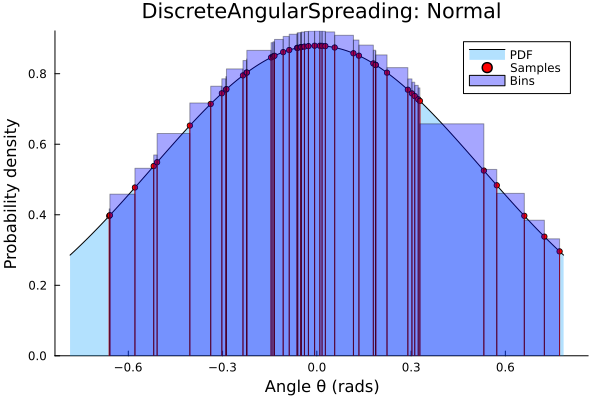

In [11]:
# Build a discrete angular spreading from the truncated Normal
nθ = 45
spread_norm = DiscreteAngularSpreading(base_dist, θmin, θmax, nθ)

angles = get_angles(spread_norm)
centers = get_central_angles(spread_norm)
bandwidths = get_bandwidths(spread_norm)
weights = get_weights(spread_norm)

println("First 5 sampled edges θ: ", angles[1:5])
println("First 5 centers θ̄:       ", centers[1:5])
println("First 5 Δθ:              ", bandwidths[1:5])
println("Normalised?   ∑ w ⋅ Δθ = ", sum(weights .* bandwidths))

p_norm = plot(spread_norm, title="DiscreteAngularSpreading: Normal")
bar!(p_norm, centers, weights, bar_width=bandwidths, label="Bins", alpha=0.35, color=:blue)

## Long-crested (single-direction) seas
Use `DiscreteAngularSpreading(θ)` (or no arguments) for a long-crested sea. Internally it creates a tiny uniform around `θ` and sets `nθ=2`, yielding one bin aligned with the chosen direction.

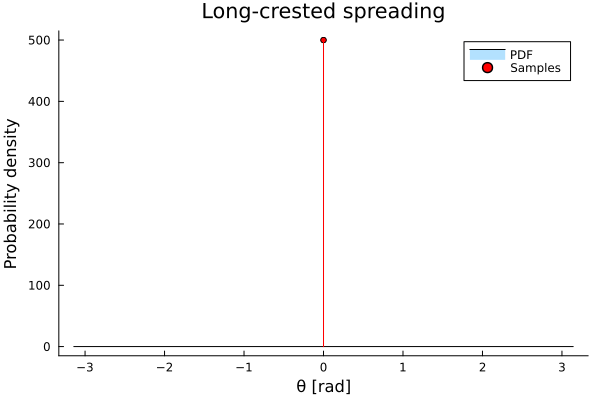

In [12]:
# Long-crested example at 45°
sm_long = DiscreteAngularSpreading()
plot(sm_long, title="Long-crested spreading", xlabel="θ [rad]")

## Reproducibility: seeds
`DiscreteAngularSpreading` stores a seed used when sampling angle edges. Use `change_seed!` to refresh or set a specific seed for reproducible bins.

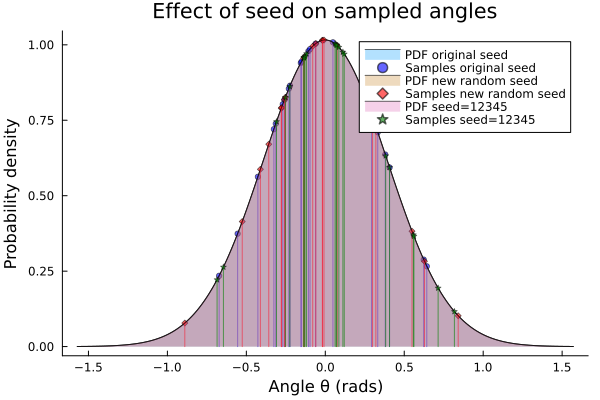

In [13]:
# Demonstrate seed control
sm1 = DiscreteAngularSpreading(:normal, 0.0, π/8, -π/2, π/2, 21)
sm2 = change_seed!(sm1)              # new random seed
sm3 = change_seed!(sm1, 12345)       # fixed seed

p_seed = plot(sm1, label="original seed", alpha=0.6, color_samples = :blue)
plot!(p_seed, sm2, label="new random seed", alpha=0.6, color_samples = :red, marker_type=:diamond)
plot!(p_seed, sm3, label="seed=12345", alpha=0.6, color_samples = :green, marker_type=:star)

title!(p_seed, "Effect of seed on sampled angles")

## Degrees vs radians
Set `units=:degrees` to pass all inputs in degrees; WaveSpec converts internally to radians. This is useful when directional data are in compass degrees.

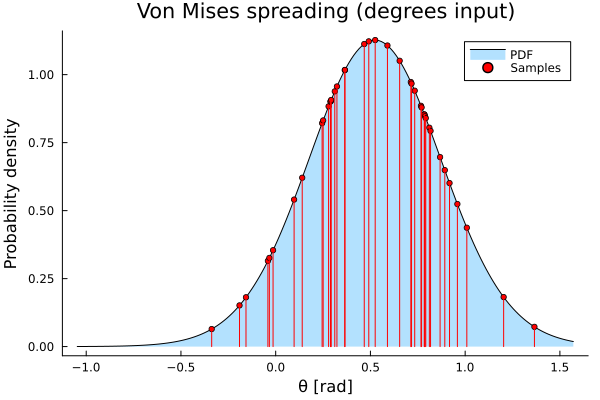

In [14]:
# Example using degrees
μ_deg = 30.0          # mean direction [deg]
σ_deg = 20.0          # std dev [deg]
θmin_deg, θmax_deg = -60.0, 90.0
nθ_deg = 41

spread_deg = DiscreteAngularSpreading(:vonmises, μ_deg, σ_deg, θmin_deg, θmax_deg, nθ_deg; units=:degrees)
plot(spread_deg, title="Von Mises spreading (degrees input)", xlabel="θ [rad]")

## Built-in angular spreading models (factory constructor)
`DiscreteAngularSpreading(model, μ, σ, a, b, nθ; units=:radians)` builds a discrete model from a symbol:
- `:uniform` — uniform on [a, b]
- `:normal` — Gaussian with mean `μ`, std `σ`
- `:cosinepow` — cosine-power (∝ cos^{2s}), parameterized from `σ`
- `:vonmises` — circular normal with concentration (κ = 1/σ^2)
- `:donelan` — Donelan–Banner (sech^2) with (β = π/(√3·σ))

All models are truncated to `[a, b]` before discretization. Set `units=:degrees` to pass parameters in degrees.

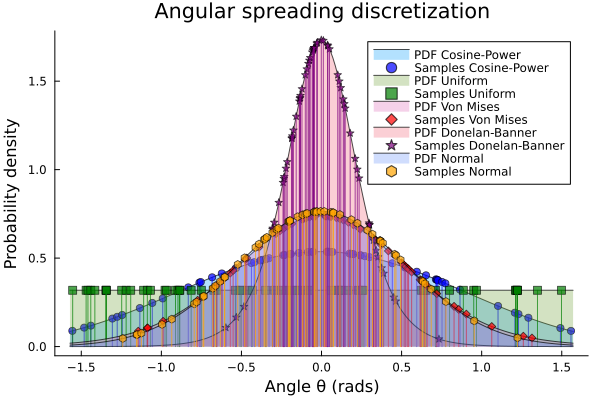

In [16]:
# Compare built-in models with the factory constructor
μ0 = 0.0
σ0 = π/6
θmin2, θmax2 = -π/2, π/2
nθ2 = 61

models = [
    (:uniform, "Uniform", :blue, :circle),
    (:normal, "Normal", :green, :square),
    (:cosinepow, "Cosine-Power", :red, :diamond),
    (:vonmises, "Von Mises", :purple, :star),
    (:donelan, "Donelan-Banner", :orange, :hexagon)
]

spreads = Dict(name => DiscreteAngularSpreading(sym, μ0, σ0, θmin2, θmax2, nθ2) for (sym, name, _, _) in models)

p_models = plot(title="Angular spreading models", xlabel="θ [rad]", ylabel="Density")
for ((name, sm), (_, _, color, marker)) in zip(spreads, models)
    plot!(p_models, sm, label=name, alpha=0.7, color_samples = color, marker_type=marker, marker_size=4)
end
p_models